In [1]:
import os
print(f"Working in: {os.getcwd()}")
print(f"Files here: {os.listdir()}")



Working in: /Users/jadepro13/Desktop/Hackfest/Hackfest
Files here: ['.DS_Store', 'requirements.txt', 'kaggle.json', '__init__.py', 'core.py', 'README.md', 'datasets.json', 'MiniDataDevs', 'loader.py', '.venv', '.git', 'analysis.ipynb', 'src']


In [ ]:
pip install matplotlib

In [ ]:
pip install seaborn

✅ DatasetLoader imported successfully!


## Available Datasets (7 total)

- **avengers**: Marvel character deaths and resurrections

- **college-majors**: Salaries by college major

- **hip-hop-lyrics**: 2016 presidential candidate mentions in hip-hop

...

,URL,Name/Alias,Appearances,Current?,Gender,Probationary Introl,Full/Reserve Avengers Intro,Year,Years since joining,Honorary,...,Return1,Death2,Return2,Death3,Return3,Death4,Return4,Death5,Return5,Notes
0,http://marvel.wikia.com/Henry_Pym_(Earth-616),"Henry Jonathan ""Hank"" Pym",1269,YES,MALE,NaN,Sep-63,1963,52,Full,...,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Merged with Ultron in Rage of Ultron Vol. 1. A...
1,http://marvel.wikia.com/Janet_van_Dyne_(Earth-...,Janet van Dyne,1165,YES,FEMALE,NaN,Sep-63,1963,52,Full,...,YES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dies in Secret Invasion V1:I8. Actually was se...
2,http://marvel.wikia.com/Anthony_Stark_(Earth-616),"Anthony Edward ""Tony"" Stark",3068,YES,MALE,NaN,Sep-63,1963,52,Full,...,YES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Death: ""Later while under the influence of Imm..."
3,http://marvel.wikia.com/Robert_Bruce_Banner_(E...,Robert Bruce Banner,2089,YES,MALE,NaN,Sep-63,1963,52,Full,...,YES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Dies in Ghosts of the Future arc. However ""he ..."
4,http://marvel.wikia.com/Thor_Odinson_(Earth-616),Thor Odinson,2402,YES,MALE,NaN,Sep-63,1963,52,Full,...,YES,YES,NO,NaN,NaN,NaN,NaN,NaN,NaN,Dies in Fear Itself brought back because that'...


### Basic Statistics

,URL,Name/Alias,Appearances,Current?,Gender,Probationary Introl,Full/Reserve Avengers Intro,Year,Years since joining,Honorary,...,Return1,Death2,Return2,Death3,Return3,Death4,Return4,Death5,Return5,Notes
count,173,163,173.000000,173,173,15,159,173.000000,173.000000,173,...,69,17,16,2,2,1,1,1,1,75
unique,173,162,NaN,2,2,12,93,NaN,NaN,4,...,2,2,2,1,2,1,1,1,1,71
top,http://marvel.wikia.com/Henry_Pym_(Earth-616),Vance Astrovik,NaN,NO,MALE,Jul-75,Sep-63,NaN,NaN,Full,...,YES,YES,NO,YES,NO,YES,YES,YES,YES,Died in New_Avengers_Vol_3_32
freq,1,2,NaN,91,115,2,6,NaN,NaN,138,...,46,16,8,2,1,1,1,1,1,4
mean,NaN,NaN,414.052023,NaN,NaN,NaN,NaN,1988.445087,26.554913,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,677.991950,NaN,NaN,NaN,NaN,30.374669,30.374669,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,1900.000000,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,58.000000,NaN,NaN,NaN,NaN,1979.000000,5.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,132.000000,NaN,NaN,NaN,NaN,1996.000000,19.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,491.000000,NaN,NaN,NaN,NaN,2010.000000,36.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Missing Values

Name/Alias                      10
Probationary Introl            158
Full/Reserve Avengers Intro     14
Return1                        104
Death2                         156
Return2                        157
Death3                         171
Return3                        171
Death4                         172
Return4                        172
Death5                         172
Return5                        172
Notes                           98
dtype: int64

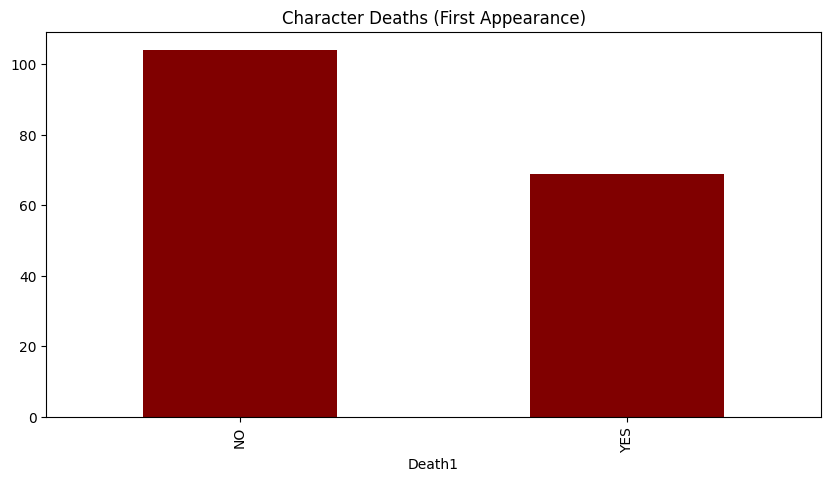

Saved processed data to: `processed_avengers.csv`

In [9]:


# Environment
import pandas as pd
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import seaborn as sns

# Import DatasetLoader
try:
    from src.data.loader import DatasetLoader
    print("✅ DatasetLoader imported successfully!")
except ImportError as e:
    print(f"❌ Error importing: {e}")
    # Fallback direct import (delete after testing)
    import sys
    sys.path.append("/Users/jade/Hackfest")  # Your exact path
    from src.data.loader import DatasetLoader

# Loader
loader = DatasetLoader()
datasets = loader.list_datasets()

display(Markdown(f"## Available Datasets ({len(datasets)} total)"))
for name, desc in datasets.items():
    display(Markdown(f"- **{name}**: {desc}"))

# Load Dataset
dataset_name = "avengers"  # Change to any key from loader.list_datasets()
df = loader.load(dataset_name)

display(Markdown(f"## First 5 rows of {dataset_name}"))
display(df.head())

# Basic Analysis
display(Markdown("### Basic Statistics"))
display(df.describe(include='all'))

display(Markdown("### Missing Values"))
missing = df.isna().sum()
display(missing[missing > 0])  # Only show columns with missing values

# Visualization Example
if dataset_name == "avengers":
    plt.figure(figsize=(10,5))
    df['Death1'].value_counts().plot(kind='bar', color='maroon')
    plt.title("Character Deaths (First Appearance)")
    plt.show()

#  Save Data
output_path = f"processed_{dataset_name}.csv"
df.to_csv(output_path, index=False)
display(Markdown(f"Saved processed data to: `{output_path}`"))
